In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [68]:
!ls

Orthogroups.tsv
Orthogroups_SingleCopyOrthologues.txt
Untitled.ipynb
allacma_fusca.dicyrtomina_minuta.orthodiver_agg.tsv
allacma_fusca.gene.AGAT.bed
allacma_fusca.lipothrix_lubbocki.orthodiver_agg.tsv
allacma_fusca.longest_isoforms.pi.tsv
allacma_fusca.sp1.SCO_genes.txt
dnds.txt
dxy.txt


In [69]:
gene_bed = pd.read_csv('allacma_fusca.gene.AGAT.bed', sep='\t', header=None)
SCOs = pd.read_csv('allacma_fusca.sp1.SCO_genes.txt', sep='\t', header=None)
sc_orthogroups = pd.read_csv('Orthogroups_SingleCopyOrthologues.txt', sep='\t', header=None)
Orthogroups = pd.read_csv('Orthogroups.tsv', sep='\t')
Orthogroups = Orthogroups[Orthogroups['Orthogroup'].isin(sc_orthogroups[0])]
Orthogroups['gene'] = Orthogroups['allacma_fusca.best.pep'].str.split('.', expand=True)[[1,2]].agg('.'.join, axis=1)

In [70]:
Orthogroups = Orthogroups.reset_index()[['Orthogroup', 'gene']]
Orthogroups['gene']  = Orthogroups['gene'].astype(str)
gene_loc = gene_bed[gene_bed[3].isin(SCOs[0])][[0,3]].rename(columns={0:'chrom',3:'gene'})
gene_loc['gene'] = gene_loc['gene'].astype(str)

In [71]:
locs = Orthogroups.merge(gene_loc, how='outer', on='gene')
locs['pi_gene'] = locs['gene'].str.split('.', expand=True)[0]
locs

,Orthogroup,gene,chrom,pi_gene
0,OG0006479,g161.t1,OX359245.1,g161
1,OG0006481,g173.t1,OX359245.1,g173
2,OG0006483,g231.t1,OX359245.1,g231
3,OG0006484,g248.t2,OX359245.1,g248
4,OG0006485,g252.t1,OX359245.1,g252
...,...,...,...,...
8877,OG0015716,g89.t1,CAMXBY010000054.1,g89
8878,OG0015717,g91.t1,CAMXBY010000055.1,g91
8879,OG0015720,g96.t1,CAMXBY010000060.1,g96
8880,OG0015722,g114.t1,CAMXBY010000065.1,g114


In [72]:
x_list = ['OX359249.1', 'OX359250.1']

In [73]:
pi_df = pd.read_csv('allacma_fusca.longest_isoforms.pi.tsv', sep='\t')
pi_df = pi_df.dropna()
pi_df['pi_gene'] = pi_df['feature'].str.split('=', expand=True)[1]
pi_sco = pi_df.merge(locs[['Orthogroup','pi_gene']], how = 'outer', on = 'pi_gene')
pi_sco = pi_sco.dropna()
pi_sco

,chrom,feature,0D_pi,4D_pi,0/4D_pi,pi_gene,Orthogroup
2,OX359245.1,ID=g161,0.003908,0.006341,0.616327,g161,OG0006479
23,OX359245.1,ID=g248,0.004946,0.001216,4.068858,g248,OG0006484
25,OX359245.1,ID=g252,0.003518,0.002927,1.201680,g252,OG0006485
33,OX359245.1,ID=g261,0.000077,0.002340,0.032970,g261,OG0006487
48,OX359245.1,ID=g346,0.000076,0.000353,0.215238,g346,OG0006501
...,...,...,...,...,...,...,...
7181,OX359250.1,ID=g23234,0.003201,0.004819,0.664136,g23234,OG0011741
7187,OX359250.1,ID=g23304,0.000374,0.000743,0.504177,g23304,OG0011772
7188,OX359250.1,ID=g23305,0.000488,0.000213,2.295652,g23305,OG0011773
7189,OX359250.1,ID=g23309,0.002945,0.001575,1.869930,g23309,OG0011775


In [74]:
pi_df[pi_df['chrom'].isin(x_list)]['0/4D_pi'].describe()

count    481.000000
mean            inf
std             NaN
min        0.000000
25%        0.417643
50%        0.820102
75%        1.616848
max             inf
Name: 0/4D_pi, dtype: float64

In [75]:
pi_df[~pi_df['chrom'].isin(x_list)]['0/4D_pi'].describe()

count    6718.000000
mean             inf
std              NaN
min         0.000000
25%         0.745115
50%         1.331114
75%         2.455218
max              inf
Name: 0/4D_pi, dtype: float64

(array([4.524e+03, 1.140e+03, 4.550e+02, 2.260e+02, 1.340e+02, 9.500e+01,
        5.100e+01, 2.900e+01, 1.800e+01, 1.100e+01, 1.200e+01, 7.000e+00,
        5.000e+00, 2.000e+00, 5.000e+00, 0.000e+00, 1.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00]),
 array([0.        , 0.00444099, 0.00888199, 0.01332298, 0.01776398,
        0.02220497, 0.02664596, 0.03108696, 0.03552795, 0.03996894,
        0.04440994, 0.04885093, 0.05329193, 0.05773292, 0.06217391,
        0.06661491, 0.0710559 , 0.07549689, 0.07993789, 0.08437888,
        0.08881988]),
 <BarContainer object of 20 artists>)

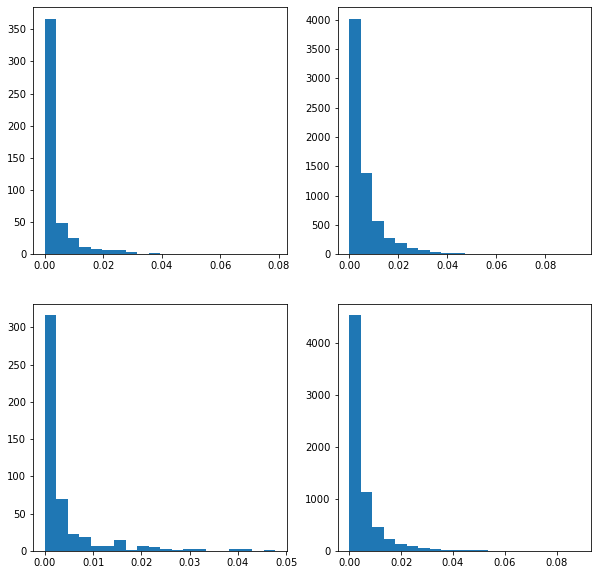

In [76]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

axs[0][0].hist(pi_df[pi_df['chrom'].isin(x_list)]['0D_pi'],
               bins = 20
)

axs[0][1].hist(pi_df[~pi_df['chrom'].isin(x_list)]['0D_pi'],
               bins = 20
)

axs[1][0].hist(pi_df[pi_df['chrom'].isin(x_list)]['4D_pi'],
               bins = 20
)

axs[1][1].hist(pi_df[~pi_df['chrom'].isin(x_list)]['4D_pi'],
               bins = 20
)

In [77]:
dxy_df = pd.read_csv('allacma_fusca.lipothrix_lubbocki.orthodiver_agg.tsv', sep='\t')
dxy_df = dxy_df.merge(locs, how = 'outer',on = 'Orthogroup')
dxy_df = dxy_df.dropna()
dxy_df

,Orthogroup,0d_pi_allacma_fusca,0d_pi_lipothrix_lubbocki,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_lipothrix_lubbocki,4d_pi_mean,0d_dxy,4d_dxy,0d_da,4d_da,dnds,alpha,gene,chrom,pi_gene
0,OG0015321,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043546,0.585065,0.043546,0.585065,0.074430,1.000000,g16817.t1,OX359248.1,g16817
1,OG0014244,0.000000,0.002498,0.001249,0.000833,0.019868,0.010351,0.048083,0.585689,0.046834,0.575338,0.082097,-0.469799,g14867.t1,OX359248.1,g14867
2,OG0008694,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031026,0.489362,0.031026,0.489362,0.063401,1.000000,g19815.t1,OX359249.1,g19815
3,OG0010121,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005181,0.333333,0.005181,0.333333,0.015544,1.000000,g7966.t1,OX359246.1,g7966
4,OG0009057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016713,0.647887,0.016713,0.647887,0.025796,1.000000,g20419.t1,OX359249.1,g20419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8004,OG0013349,0.000089,0.000000,0.000044,0.000421,0.000000,0.000210,0.044684,0.626473,0.044640,0.626263,0.071326,-1.956296,g12695.t1,OX359247.1,g12695
8005,OG0013174,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.026188,0.658416,0.026188,0.658416,0.039775,1.000000,g12331.t1,OX359247.1,g12331
8006,OG0010845,0.000000,0.000000,0.000000,0.000689,0.000000,0.000344,0.072774,0.603375,0.072774,0.603030,0.120612,1.000000,g21611.t1,OX359250.1,g21611
8007,OG0011277,0.000000,0.000000,0.000000,0.000563,0.000000,0.000282,0.029046,0.452984,0.029046,0.452703,0.064121,1.000000,g22394.t1,OX359250.1,g22394


In [78]:
dxy_df[dxy_df['chrom'].isin(x_list)]['dnds'].describe()

count    3099.000000
mean        0.067165
std         0.052480
min         0.000000
25%         0.032537
50%         0.056159
75%         0.090412
max         1.121495
Name: dnds, dtype: float64

In [79]:
dxy_df[~dxy_df['chrom'].isin(x_list)]['dnds'].describe()

count    4903.000000
mean        0.075405
std         0.050377
min         0.000000
25%         0.039043
50%         0.065667
75%         0.100505
max         0.513080
Name: dnds, dtype: float64

(0.0, 0.5)

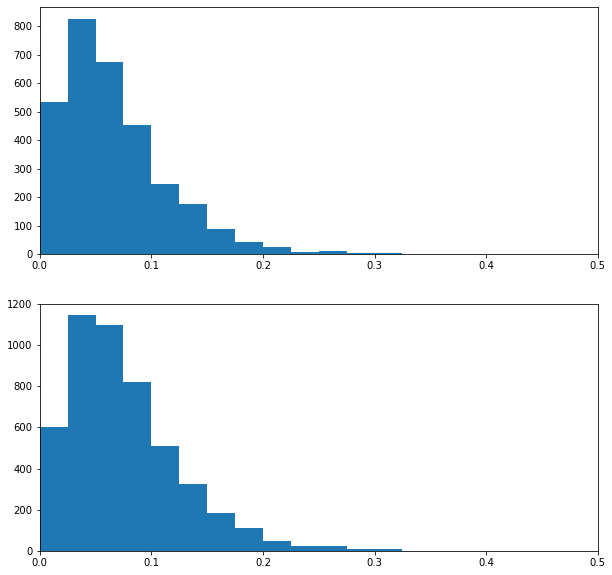

In [80]:
fig, axs = plt.subplots(nrows = 2, figsize = (10, 10))

axs[0].hist(dxy_df[dxy_df['chrom'].isin(x_list)]['dnds'],
               bins = np.arange(0, 0.5, 0.025)
)

axs[1].hist(dxy_df[~dxy_df['chrom'].isin(x_list)]['dnds'],
               bins = np.arange(0, 0.5, 0.025)
)

axs[0].set_xlim(0, 0.5)
axs[1].set_xlim(0, 0.5)

In [81]:
pi_dxy_df = dxy_df.merge(pi_sco, how = 'outer',on = 'Orthogroup')
pi_dxy_df = pi_dxy_df.dropna()
pi_dxy_df['gene_pop_alpha'] = 1 - (pi_dxy_df['0/4D_pi']/pi_dxy_df['dnds'])
pi_dxy_df.replace([np.inf, -np.inf], np.nan, inplace=True)
pi_dxy_df.gene_pop_alpha.quantile(0.95)
pi_dxy_df

,Orthogroup,0d_pi_allacma_fusca,0d_pi_lipothrix_lubbocki,0d_pi_mean,4d_pi_allacma_fusca,4d_pi_lipothrix_lubbocki,4d_pi_mean,0d_dxy,4d_dxy,0d_da,...,gene,chrom_x,pi_gene_x,chrom_y,feature,0D_pi,4D_pi,0/4D_pi,pi_gene_y,gene_pop_alpha
6,OG0009556,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.125774,0.388889,0.125774,...,g5945.t1,OX359246.1,g5945,OX359246.1,ID=g5945,0.019509,0.026996,0.722672,g5945,-1.234477
7,OG0014186,0.000000,0.0,0.000000,0.004861,0.024525,0.014693,0.013998,0.648853,0.013998,...,g14774.t1,OX359248.1,g14774,OX359248.1,ID=g14774,0.005092,0.002372,2.147089,g14774,-98.522032
22,OG0014919,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.039312,0.600000,0.039312,...,g16099.t1,OX359248.1,g16099,OX359248.1,ID=g16099,0.000386,0.001574,0.245347,g16099,-2.744639
26,OG0015253,0.000000,0.0,0.000000,0.000000,0.050000,0.025000,0.055929,0.525000,0.055929,...,g16695.t1,OX359248.1,g16695,OX359248.1,ID=g16695,0.006711,0.004076,1.646465,g16695,-14.455225
27,OG0014161,0.000142,0.0,0.000071,0.000000,0.000000,0.000000,0.036576,0.504486,0.036505,...,g14714.t1,OX359248.1,g14714,OX359248.1,ID=g14714,0.000481,0.000828,0.581274,g14714,-7.017407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7983,OG0006878,0.000000,0.0,0.000000,0.000000,0.083686,0.041843,0.075287,0.577436,0.075287,...,g1689.t1,OX359245.1,g1689,OX359245.1,ID=g1689,0.001996,0.002074,0.962514,g1689,-6.382334
7989,OG0012939,0.001057,0.0,0.000529,0.003268,0.000000,0.001634,0.054324,0.580065,0.053795,...,g11698.t1,OX359247.1,g11698,OX359247.1,ID=g11698,0.002028,0.006119,0.331348,g11698,-2.538099
7993,OG0012866,0.000935,0.0,0.000468,0.006442,0.000000,0.003221,0.110719,0.636045,0.110251,...,g11530.t1,OX359247.1,g11530,OX359247.1,ID=g11530,0.003719,0.003755,0.990401,g11530,-4.689544
7997,OG0013349,0.000089,0.0,0.000044,0.000421,0.000000,0.000210,0.044684,0.626473,0.044640,...,g12695.t1,OX359247.1,g12695,OX359247.1,ID=g12695,0.000135,0.000305,0.441034,g12695,-5.183321


(array([126., 383., 396., 259., 150.,  81.,  27.,  11.,   4.,   3.]),
 array([0.        , 0.03234188, 0.06468377, 0.09702565, 0.12936754,
        0.16170942, 0.19405131, 0.22639319, 0.25873508, 0.29107696,
        0.32341885]),
 <BarContainer object of 10 artists>)

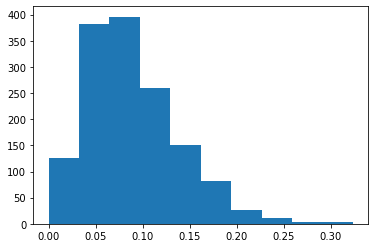

In [85]:
plt.hist(pi_dxy_df[~pi_dxy_df.chrom_x.isin(x_list)]['dnds'])

(array([ 3., 33., 53., 28., 24., 19., 26.,  9.,  6.,  4.]),
 array([0.        , 0.01998411, 0.03996821, 0.05995232, 0.07993643,
        0.09992053, 0.11990464, 0.13988875, 0.15987285, 0.17985696,
        0.19984106]),
 <BarContainer object of 10 artists>)

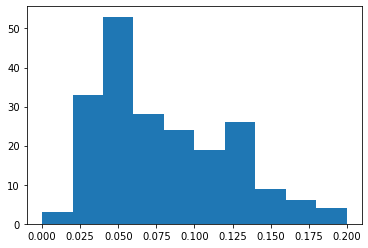

In [84]:
plt.hist(pi_dxy_df[pi_dxy_df.chrom_x.isin(x_list)]['dnds'])

(array([ 5.,  6.,  6.,  7., 14.,  9.,  8.,  3.,  2.,  3.]),
 array([0.03220509, 0.05356714, 0.07492919, 0.09629124, 0.1176533 ,
        0.13901535, 0.1603774 , 0.18173945, 0.2031015 , 0.22446355,
        0.2458256 ]),
 <BarContainer object of 10 artists>)

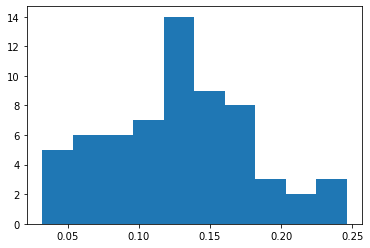

In [89]:
plt.hist(pi_dxy_df[(pi_dxy_df['gene_pop_alpha']>-1.06) & ~(pi_dxy_df.chrom_x.isin(x_list))]['dnds'])

(array([2., 2., 1., 2., 2., 4., 2., 1., 0., 1.]),
 array([0.04276915, 0.05847634, 0.07418353, 0.08989072, 0.10559792,
        0.12130511, 0.1370123 , 0.15271949, 0.16842668, 0.18413387,
        0.19984106]),
 <BarContainer object of 10 artists>)

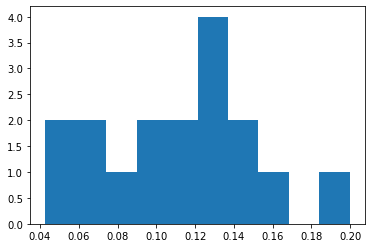

In [90]:
plt.hist(pi_dxy_df[(pi_dxy_df['gene_pop_alpha']>-1.06) & (pi_dxy_df.chrom_x.isin(x_list))]['dnds'])

In [103]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['0d_pi_allacma_fusca']>0) & (dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    63.000000
mean      0.071880
std       0.045310
min       0.009514
25%       0.040380
50%       0.056159
75%       0.095783
max       0.223169
Name: dnds, dtype: float64

In [104]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['0d_pi_allacma_fusca']>0) & (~dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    592.000000
mean       0.084068
std        0.046951
min        0.005889
25%        0.048673
50%        0.075295
75%        0.110229
max        0.262647
Name: dnds, dtype: float64

In [105]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['alpha']>0) & (dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    301.000000
mean       0.059165
std        0.042238
min        0.000000
25%        0.028863
50%        0.047834
75%        0.081556
max        0.200483
Name: dnds, dtype: float64

In [101]:
dxy_df[(dxy_df['4d_pi_allacma_fusca']>0) & (dxy_df['alpha']>0) & (~dxy_df['chrom'].isin(x_list))]['dnds'].describe()

count    208.000000
mean       0.095322
std        0.050556
min        0.007730
25%        0.057487
50%        0.084675
75%        0.122593
max        0.262647
Name: dnds, dtype: float64

In [ ]:
# maybe i can change it so i use gene_pop pnps if ortholog_pop_gen pnps is not available, not exclusively using one or the other. how could it not be available from gene pop if it is from ortholog pop gen though?